## AVIATION RISK ANALYSIS PROJECT



## STEP1: Business Understanding

The company is expanding into aviation and wants to minimize operational and financial risk.
The goal of this project is to identify aircraft types with the lowest safety risk
based on historical accident data.

## 1.1 Business questions to investigate
1. Which aircraft manufacturers have the lowest accident severity?
2. Which aircraft categories show the lowest fatality rates?
3. How has aviation safety changed over time?

## STEP2: Data Understanding

The dataset contains aviation accident records from 1962 to 2023. It includes aircraft manufacturer, model, accident date, injury counts, and damage severity. Due to the long time span and reporting differences, several fields may contain missing values.

### 2.1 Loading Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
import os
os.getcwd()

'c:\\Users\\codhiambo\\Documents\\Flatiron\\phase1\\Project1\\Phase1_Aviation_Project'

### 2.2 Load dataset

In [ ]:
import pandas as pd

df = pd.read_csv("flight.csv", low_memory=False) #Load the data, read CSV file and turns it into a pandas DF.


### 2.3 Inspect data
 

In [ ]:
df.head()
#I have"peeked" at the data and checked that it loaded correctly, nature of column names, kind of data & problems.
# some of the column heads include accident date, airline operator, fatalities etc.

,Unnamed: 0,acc.date,type,reg,operator,fat,location,dmg
0,0,03-Jan-22,British Aerospace 4121 Jetstream 41,ZS-NRJ,SA Airlink,0,near Venetia Mine Airport,sub
1,1,04-Jan-22,British Aerospace 3101 Jetstream 31,HR-AYY,LANHSA - Línea Aérea Nacional de Honduras S.A,0,Roatán-Juan Manuel Gálvez International Airpor...,sub
2,2,05-Jan-22,Boeing 737-4H6,EP-CAP,Caspian Airlines,0,Isfahan-Shahid Beheshti Airport (IFN),sub
3,3,08-Jan-22,Tupolev Tu-204-100C,RA-64032,"Cainiao, opb Aviastar-TU",0,Hangzhou Xiaoshan International Airport (HGH),w/o
4,4,12-Jan-22,Beechcraft 200 Super King Air,NaN,private,0,"Machakilha, Toledo District, Grahem Creek area",w/o


In [ ]:
#I want to see the last few rows
df.tail()

,Unnamed: 0,acc.date,type,reg,operator,fat,location,dmg
2495,1245,20-Dec-18,Cessna 560 Citation V,N188CW,Chen Aircrafts LLC,4,"2 km NE of Atlanta-Fulton County Airport, GA (...",w/o
2496,1246,22-Dec-18,PZL-Mielec M28 Skytruck,GNB-96107,Guardia Nacional Bolivariana de Venezuela - GNBV,0,Kamarata Airport (KTV),sub
2497,1247,24-Dec-18,Antonov An-26B,9T-TAB,Air Force of the Democratic Republic of the Congo,0,Beni Airport (BNC),w/o
2498,1248,31-Dec-18,Boeing 757-2B7 (WL),N938UW,American Airlines,0,"Charlotte-Douglas International Airport, NC (C...",sub
2499,1249,unk. date 2018,Rockwell Sabreliner 80,N337KL,private,0,"Eugene Airport, OR (EUG)",sub


In [ ]:
df.shape
# I can see we have 2500 rows and 8 colums

(2500, 8)

In [ ]:
df.columns
# Viewing a list of all column names

Index(['Unnamed: 0', 'acc.date', 'type', 'reg', 'operator', 'fat', 'location',
       'dmg'],
      dtype='object')

In [ ]:
# I need to seethe data types and missing values count. A very useful information of course
df.info()
# I can see that 'almost' no missing data in key columns as would have been expected of the thoroughness of aviation data
# Small issues can be observed:1)Unnamed: 0 → useless, so will drop it (2)Dates are strings → convert to datetime (3)Fat (fatalities) is string → clean/convert to numeric.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  2500 non-null   int64 
 1   acc.date    2500 non-null   object
 2   type        2500 non-null   object
 3   reg         2408 non-null   object
 4   operator    2486 non-null   object
 5   fat         2488 non-null   object
 6   location    2500 non-null   object
 7   dmg         2500 non-null   object
dtypes: int64(1), object(7)
memory usage: 156.4+ KB


In [ ]:
df.describe()
#looking at the basic statistics for numeric columns - mean, std etc

,Unnamed: 0
count,2500.000000
mean,624.500000
std,360.915993
min,0.000000
25%,312.000000
50%,624.500000
75%,937.000000
max,1249.000000


### 2.4 Check missing values

In [ ]:
df.isna().sum().sort_values(ascending=False)

reg           92
operator      14
fat           12
Unnamed: 0     0
type           0
acc.date       0
location       0
dmg            0
dtype: int64

#### The dataset contains aviation accident records from 1962 to 2023. Several columns contain missing values, particularly in registration, operator, and fatalaties. These will be handled through filtering, zero imputation.

## STEP3: Data Cleaning and Preparation (Pandas Focus)
### 3.1 Select Relevant columns

In [ ]:
columns_of_interest = [
    "acc.date",
    "type",
    "reg",
    "fat",
    "operator",
    "dmg" ,   
]

aviation = df[columns_of_interest].copy()

###### 
This line creates a new DataFrame aviation that contains only the columns I care about from df, and it’s independent of the original df. I can now work on aviation safely without altering df. The data is stored in a new variable called aviation

### 3.2 Convert date

In [ ]:
aviation["acc.date"] = pd.to_datetime(aviation["acc.date"], errors="coerce")
aviation["Year"] = aviation["acc.date"].dt.year

C:\Users\codhiambo\AppData\Local\Temp\ipykernel_19520\3242270184.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  aviation["acc.date"] = pd.to_datetime(aviation["acc.date"], errors="coerce")


In [ ]:
aviation.head()


,acc.date,type,reg,fat,operator,dmg,Year
0,2022-01-03,British Aerospace 4121 Jetstream 41,ZS-NRJ,0,SA Airlink,sub,2022.0
1,2022-01-04,British Aerospace 3101 Jetstream 31,HR-AYY,0,LANHSA - Línea Aérea Nacional de Honduras S.A,sub,2022.0
2,2022-01-05,Boeing 737-4H6,EP-CAP,0,Caspian Airlines,sub,2022.0
3,2022-01-08,Tupolev Tu-204-100C,RA-64032,0,"Cainiao, opb Aviastar-TU",w/o,2022.0
4,2022-01-12,Beechcraft 200 Super King Air,NaN,0,private,w/o,2022.0


##### 
Date converted successfully

### 3.3 Handle missing data

In [ ]:
columns_with_missing = ["reg", "operator", "fat"]
df[columns_with_missing] = df[columns_with_missing].fillna(0)
aviation[columns_with_missing] = aviation[columns_with_missing].fillna(0)

### 3.4 Renaming the Aviation columns

In [ ]:
aviation = aviation.rename(columns={
    'acc.date': 'AccidentDate',
    'type': 'AircraftType',
    'reg': 'Registration',
    'fat': 'Fatalities',
    'operator': 'Operator',
    'dmg': 'Damage',
    'Year': 'YearOfIncident'
})

In [ ]:
#Check results
aviation.columns

Index(['AccidentDate', 'AircraftType', 'Registration', 'Fatalities',
       'Operator', 'Damage', 'YearOfIncident'],
      dtype='object')

## STEP4: Data Analysis (Answer business questions)

### 4.1 Which manufacturers have the lowest fatality risk?

In [ ]:
aviation["Fatalities"] = pd.to_numeric(aviation["Fatalities"], errors="coerce")
manufacturer_risk = (
    aviation
    .groupby("AircraftType")
    .agg(
        accidents=("AircraftType", "count"),
        total_fatalities=("Fatalities", "sum")
    )
    .query("accidents >= 50")
    .sort_values("total_fatalities")
)

### 4.1.1 Visualization

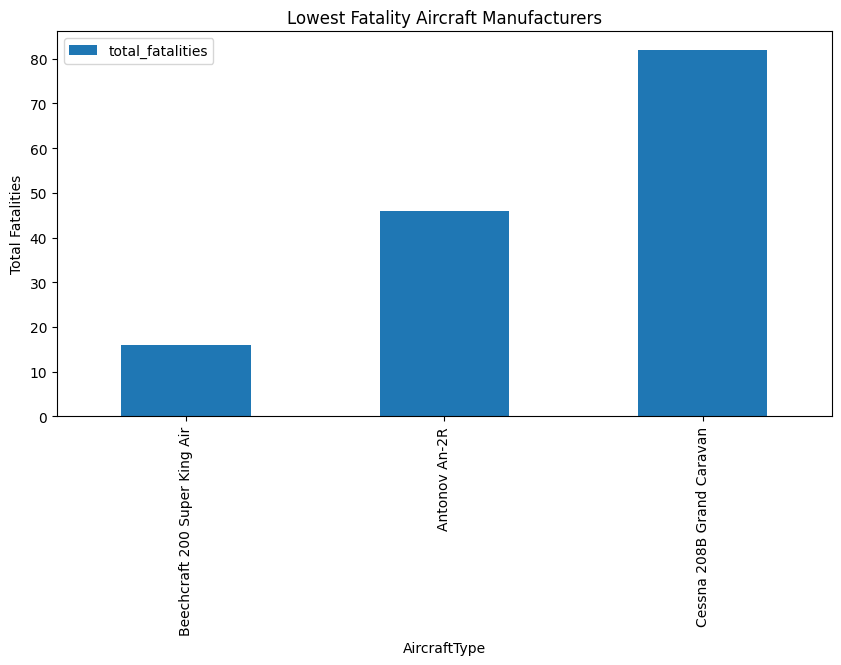

In [ ]:
manufacturer_risk.head(10).plot(
    kind="bar",
    y="total_fatalities",
    figsize=(10,5),
    title="Lowest Fatality Aircraft Manufacturers"
)
plt.ylabel("Total Fatalities")
plt.show()

#### On this question Beechcraft 200 Super King Air reports the least fatalities at below 20 and is therefore the safest. Other makes reporting low fatalities Antonov An-2R and Cessna 208B Grand Caravan. This analysis recommends the three for safety passenger safety is this is to be the top consideration.

## 4.2 Which aircraft categories are safest? 

In [ ]:
category_risk = (
    aviation
    .groupby("AircraftType")
    .agg(
        accidents=("AircraftType", "count"),
        fatalities=("Fatalities", "sum")
    )
    .sort_values("fatalities")
)

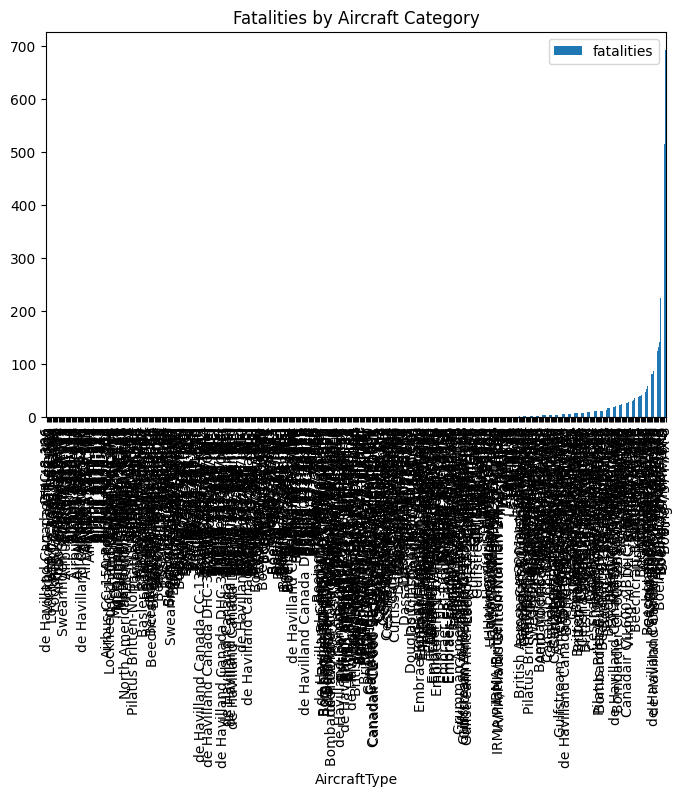

In [ ]:
category_risk.plot(
    kind="bar",
    y="fatalities",
    title="Fatalities by Aircraft Category",
    figsize=(100,50)
)
plt.show()

### This visual is jungle up. But we can see that some models of Aircraft have nearly 0 fatalities over the entire period.Aircraft type thus plays a big role on risk exposures.

## 4.3 How has aviation safety changed over time? 

In [ ]:
yearly_trend = (
    aviation
    .groupby("YearOfIncident")
    .agg(
        accidents=("YearOfIncident", "count"),
        fatalities=("Fatalities", "sum")
    )
)

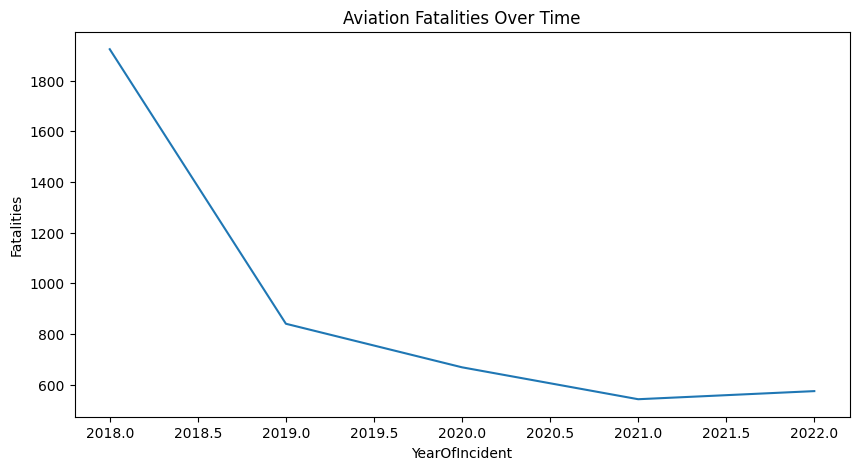

In [ ]:
yearly_trend["fatalities"].plot(
    figsize=(10,5),
    title="Aviation Fatalities Over Time"
)
plt.ylabel("Fatalities")
plt.show()

## 
We notice that overally, fatalities have reduced. This can be attributed to improved technologies and efficiently managed flight safety towards 2022. So irrespective of the model, there is a down ward trend in tomes of injuries and deaths to passengers.

## STEP5: Business Recommendations
1. It is worth giving priority to aircraft manufacturers with consistently low fatality counts
   across a large number of historical flights.

2. Initial investments should focus on aircraft categories with lower fatality rates,
   Though this is not clear from visual two, but we can see that aircraft on the left of plot report low fatalities.

3. Invest in modern aircraft models, as historical trends show improved safety
   outcomes in recent decades.